In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

pd.pandas.set_option('display.max_columns', None)

In [2]:

features = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header=None)
edges = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')
classes = pd.read_csv('../data/raw/archive/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')

print(features.shape, edges.shape, classes.shape)

(203769, 167) (234355, 2) (203769, 2)


In [3]:

classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [4]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [5]:
features.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

In [6]:
features.columns=['txId', 'time_step'] + [f'feature_{i}' for i in range(1, 166)]   
features.head()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236

In [7]:
def Null_values(df):
    null_values = df.isnull().sum()
    null_values = null_values[null_values > 0]
    null_values.sort_values(inplace=True)
    return null_values

In [8]:
print(Null_values(features).head())
print(Null_values(edges).head())
print(Null_values(classes).head())

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


In [9]:
print(classes['class'].unique())
print(classes['class'].dtype)

<StringArray>
['unknown', '2', '1']
Length: 3, dtype: str
str


In [10]:
print(features['txId'].duplicated().sum())
print(classes['txId'].duplicated().sum())
print(edges['txId1'].duplicated().sum())
print(edges['txId2'].duplicated().sum())

0
0
68010
85908


In [11]:
print(edges.duplicated().sum())

0


In [12]:
merged = features.merge(classes, on='txId')
print(merged.shape)
merged.head()   

(203769, 168)


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.22

In [13]:
merged.nunique().sort_values().head(10)

class            3
feature_3        9
feature_113      9
feature_112      9
feature_148      9
feature_149      9
time_step       49
feature_15      51
feature_160     90
feature_7      108
dtype: int64

In [14]:

sorted(features['feature_3'].unique())

[np.float64(-1.756361477431697),
 np.float64(-1.2013688016765636),
 np.float64(-0.6463761259214303),
 np.float64(-0.0913834501662971),
 np.float64(0.463609225588836),
 np.float64(1.018601901343969),
 np.float64(1.5735945770991024),
 np.float64(2.128587252854236),
 np.float64(2.683579928609369)]

## Low-cardinality feature check
Checked unique values for all columns flagged with low nunique() counts
(feature_3, feature_7, feature_15, feature_112, feature_113, feature_118,
feature_148, feature_149, feature_160). All show the same pattern as
feature_3 — pre-scaled decimal/negative values, not raw counts or broken
data. No features dropped.

In [15]:
low_card_cols = ['feature_3', 'feature_112', 'feature_113', 'feature_148', 
                  'feature_149', 'feature_15', 'feature_160', 'feature_7', 'feature_118']

for col in low_card_cols:
    print(col, '->', sorted(features[col].unique()))

feature_3 -> [np.float64(-1.756361477431697), np.float64(-1.2013688016765636), np.float64(-0.6463761259214303), np.float64(-0.0913834501662971), np.float64(0.463609225588836), np.float64(1.018601901343969), np.float64(1.5735945770991024), np.float64(2.128587252854236), np.float64(2.683579928609369)]
feature_112 -> [np.float64(-1.6263847082437624), np.float64(-1.0963356939258175), np.float64(-0.5662866796078726), np.float64(-0.0362376652899277), np.float64(0.4938113490280171), np.float64(1.023860363345962), np.float64(1.5539093776639068), np.float64(2.083958391981852), np.float64(2.6140074062997964)]
feature_113 -> [np.float64(-1.781033567057882), np.float64(-1.2673399140326196), np.float64(-0.7536462610073574), np.float64(-0.2399526079820951), np.float64(0.2737410450431671), np.float64(0.7874346980684294), np.float64(1.3011283510936915), np.float64(1.8148220041189536), np.float64(2.3285156571442163)]
feature_148 -> [np.float64(-1.5119096318869902), np.float64(-0.968902874660573), np.fl

## Low-cardinality feature investigation
Batch-checked all 9 flagged low-cardinality columns. Two distinct patterns:
1. feature_3, feature_112, feature_113, feature_148, feature_149 — exactly
   9 evenly-spaced values, consistent with a scaled small integer count.
2. feature_15, feature_160, feature_7, feature_118 — more unique values,
   evenly spaced at the low end but with a long right tail of large,
   irregularly-spaced values. This right-skewed shape is consistent with
   degree/count-like features common in transaction networks (most nodes
   have few connections, a small number act as hubs with many).
No constant (nunique()==1) columns found. No features dropped at this stage.

In [16]:
features.describe()

,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
count,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+0

In [17]:
desc = features.describe().T  # transpose so each row is one feature
desc[['min', 'max']].sort_values('min').head(10)   # most extreme low values
desc[['min', 'max']].sort_values('max', ascending=False).head(10)  # most extreme high values

,min,max
txId,1076.000000,4.032446e+08
feature_36,-0.023045,2.892044e+02
feature_34,-0.024669,2.878915e+02
feature_37,-0.026215,2.805662e+02
feature_35,-0.031272,2.697012e+02
feature_14,-0.063200,2.652632e+02
feature_5,-0.063725,2.600907e+02
feature_161,-0.125939,2.518490e+02
feature_162,-0.131155,2.387835e+02
feature_130,-0.124895,2.244587e+02


## Placeholder value check
Scanned min/max across all 165 features via describe(). No suspicious
disconnected extreme values found (e.g., -1, 999999 sitting isolated from
a feature's normal range) — consistent with the dataset being pre-cleaned
by the provider before release.

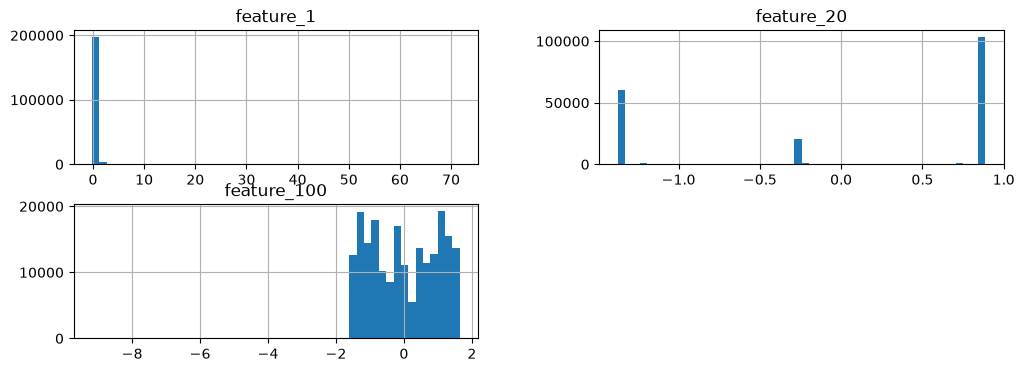

In [18]:
features[['feature_1', 'feature_20', 'feature_100']].hist(bins=50, figsize=(12,4))
plt.show()

## Distribution spot-check (feature_1, feature_20, feature_100)
Three distinct shapes observed:
- feature_1: extreme right-skew — dominant spike near 0, long thin tail to ~70.
  Consistent with a standardized count/degree-like feature.
- feature_20: discrete/clustered — 3-4 separated spikes rather than a
  continuous spread, suggesting an originally categorical or flag-like
  underlying feature.
- feature_100: more continuous, blocky spread across ~-2 to 2, no dominant
  spike — behaves like a genuinely continuous aggregated statistic.
Confirms features are not uniform in behavior; at least 3 distinct
distribution "types" exist across the 165 features.

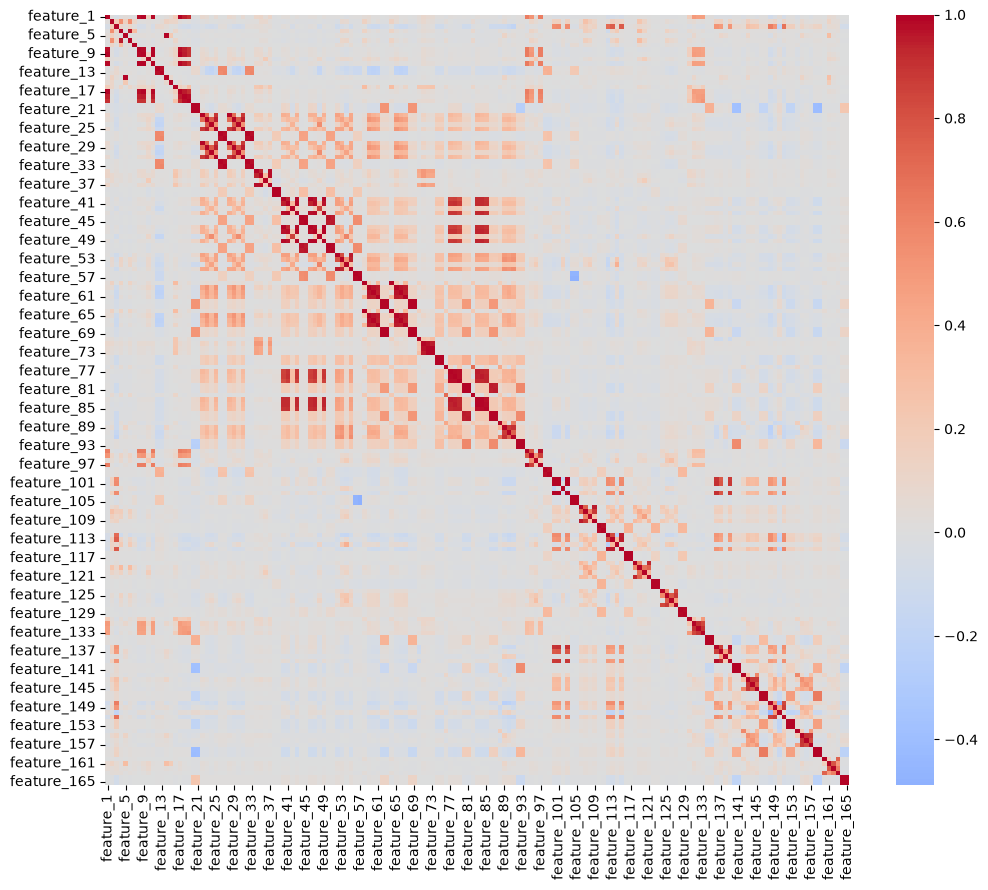

In [19]:
corr_matrix = features.iloc[:, 2:].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.show()

## Correlation heatmap
Most feature pairs show near-zero correlation (majority of the grid is
neutral/gray). Small clusters of high correlation appear between adjacent
features (e.g., ~feature_21-29, feature_41-53, feature_77-93), consistent
with the dataset's documented structure — aggregated neighbor statistics
(max, min, std, correlation) computed in related groups for the same
underlying quantity. No features dropped based on this — same full
feature set will be used for both XGBoost and GNN per the earlier
decision to keep comparisons fair.

In [20]:

outlier_counts = (features.iloc[:, 2:].abs() > 3).sum().sort_values(ascending=False)
outlier_counts.head(10)

feature_111    17189
feature_110    15826
feature_123    13642
feature_117    13593
feature_116    13590
feature_122    13467
feature_44     12914
feature_45     12851
feature_50     12779
feature_51     12737
dtype: int64

## Outlier check (±3 std threshold)
Top outlier-prone features: feature_111 (17,189 rows, ~8.4%), feature_110,
feature_123, feature_117, feature_116, feature_122, feature_44, feature_45,
feature_50, feature_51. These overlap with the correlated feature clusters
identified in the heatmap (feature_41-53, feature_101-133 ranges) —
consistent with grouped aggregation statistics derived from the same
underlying skewed quantity. No outlier removal performed at this stage;
likely reflects genuine transaction-volume/connectivity signal relevant
to fraud detection, not data quality issues.

In [21]:
print(merged['class'].value_counts())
print(merged['class'].value_counts(normalize=True) * 100)

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
class
unknown    77.148634
2          20.620899
1           2.230467
Name: proportion, dtype: float64


## Class Imbalance — Overall Distribution
merged['class'].value_counts():
  unknown: 157,205 (77.15%)
  licit ('2'): 42,019 (20.62%)
  illicit ('1'): 4,545 (2.23%)

Matches documented dataset split closely (77% / 21% / 2%), confirming
correct data loading and merge. Within labeled data only (licit + illicit,
n=46,564), illicit represents ~9.76% — still meaningfully imbalanced,
which is why plain accuracy will be misleading: a model predicting
"licit" for every transaction would score ~90% accuracy on labeled data
while catching zero fraud cases. Precision, Recall, F1, and PR-AUC on the
illicit class will be used as the primary evaluation metrics instead.

In [22]:
temporal_dist = merged.groupby(['time_step', 'class']).size().unstack(fill_value=0)
print(temporal_dist)

class        1     2  unknown
time_step                    
1           17  2130     5733
2           18  1099     3427
3           11  1268     5342
4           30  1410     4253
5            8  1874     4921
6            5   480     3843
7          102  1101     4845
8           67  1098     3292
9          248   530     4218
10          18   954     5755
11         131   565     3600
12          16   490     1541
13         291   518     3719
14          43   374     1605
15         147   471     3021
16         128   402     2445
17          99   712     2574
18          52   337     1587
19          80   665     2761
20         260   640     3391
21         100   541     2896
22         158  1605     4131
23          53  1134     2978
24         137   989     3466
25         118   476     1720
26          96   421     2006
27          24   182      883
28          85   199     1369
29         329   845     3101
30          83   441     1959
31         106   604     2106
32        

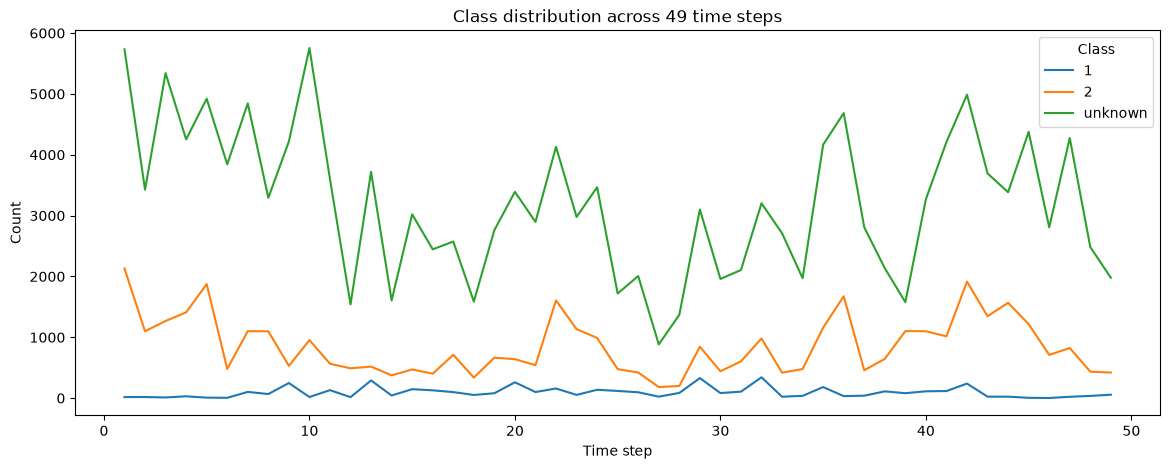

In [23]:
temporal_dist.plot(figsize=(14,5))
plt.title("Class distribution across 49 time steps")
plt.xlabel("Time step")
plt.ylabel("Count")
plt.legend(title='Class')
plt.show()

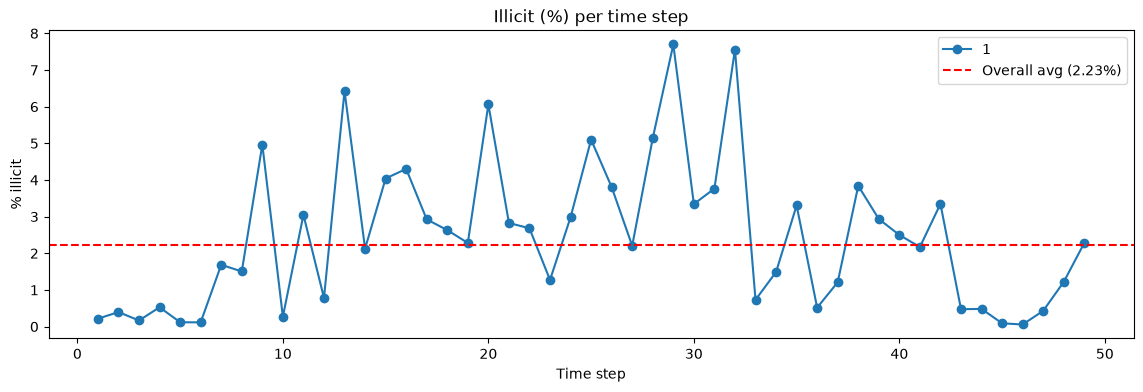

In [24]:
temporal_pct = temporal_dist.div(temporal_dist.sum(axis=1), axis=0) * 100
temporal_pct['1'].plot(figsize=(14,4), marker='o')
plt.title("Illicit (%) per time step")
plt.xlabel("Time step")
plt.ylabel("% illicit")
plt.axhline(y=2.23, color='red', linestyle='--', label='Overall avg (2.23%)')
plt.legend()
plt.show()

In [25]:

temporal_dist.loc[43:49]


class,1,2,unknown
time_step,,,
43,24,1346,3693
44,24,1567,3384
45,5,1216,4377
46,2,710,2807
47,22,824,4275
48,36,435,2483
49,56,420,1978


## Temporal Train/Val/Test Split — Decision
Chosen split: train = time steps 1-34, validation = 35-42, test = 43-49.

Verified test set (43-49) contains 169 illicit and 6,518 licit labeled
transactions (illicit rate ~2.53%, consistent with the overall 2.23%
average) — sufficient volume for stable evaluation metrics despite
individual time steps within this range showing lower illicit percentages
(as low as 0.4% at step 46). Split preserves temporal order: model is
always trained on earlier transactions and evaluated on later ones,
avoiding lookahead leakage. Illicit rate is highly volatile across time
steps overall (0.1%-7.7%, per earlier plot), which is expected in
real-world fraud patterns and is why per-class metrics (Precision,
Recall, F1, PR-AUC) will be used rather than accuracy.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.DiGraph()

In [28]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [29]:
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

In [30]:
print(G)

DiGraph with 203769 nodes and 234355 edges


In [31]:
print(G.number_of_edges())

234355


In [32]:
G.is_directed()

True

In [34]:
print(f"Graph type      : {type(G).__name__}")
print(f"Nodes           : {G.number_of_nodes():,}")
print(f"Edges           : {G.number_of_edges():,}")
print(f"Directed        : {G.is_directed()}")

Graph type      : DiGraph
Nodes           : 203,769
Edges           : 234,355
Directed        : True


In [35]:
print("="*50)
print("Graph Summary")
print("="*50)

print(f"Number of Nodes      : {G.number_of_nodes():,}")
print(f"Number of Edges      : {G.number_of_edges():,}")
print(f"Directed             : {G.is_directed()}")
print(f"Self Loops           : {nx.number_of_selfloops(G)}")
print(f"Graph Density        : {nx.density(G):.8f}")

Graph Summary
Number of Nodes      : 203,769
Number of Edges      : 234,355
Directed             : True
Self Loops           : 0
Graph Density        : 0.00000564


In [46]:
node = list(G.nodes())[0]

In [47]:
ego = nx.ego_graph(
    G,
    node,
    radius=2
)

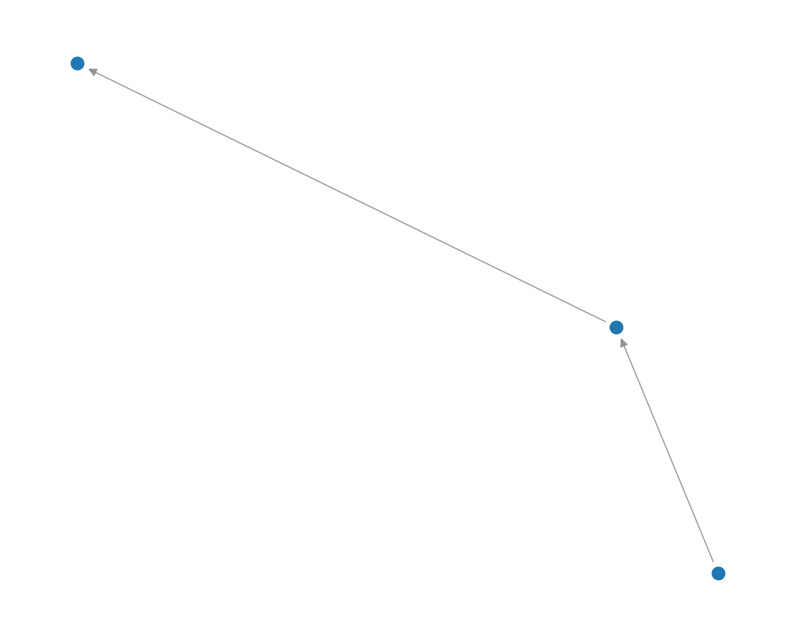

In [48]:

plt.figure(figsize=(10,8))

pos = nx.spring_layout(ego, seed=24)

nx.draw_networkx_nodes(
    ego,
    pos,
    node_size=80
)

nx.draw_networkx_edges(
    ego,
    pos,
    arrows=True,
    arrowsize=12,
    edge_color="gray",
    alpha=0.7
)

plt.axis("off")
plt.show()

In [49]:
sample_edges = edges.sample(
    500,
    random_state=42
)

sample_graph = nx.from_pandas_edgelist(
    sample_edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

In [50]:
import numpy as np

degrees = dict(G.degree())
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print(f"Average degree: {np.mean(list(degrees.values())):.2f}")
print(f"Max degree: {np.max(list(degrees.values()))}")
print(f"Average in-degree: {np.mean(list(in_degrees.values())):.2f}")
print(f"Average out-degree: {np.mean(list(out_degrees.values())):.2f}")

Average degree: 2.30
Max degree: 473
Average in-degree: 1.15
Average out-degree: 1.15


## Degree Distribution
Average degree: 2.30 (in: 1.15, out: 1.15) — most transactions connect to
only ~2 others, consistent with typical Bitcoin transactions having few
inputs/outputs. Max degree: 473 — a small number of hub-like transactions
with dramatically higher connectivity than average, consistent with the
right-skewed feature patterns identified in Phase 3. [Add hub node's class
label once checked.]

In [51]:
components = list(nx.weakly_connected_components(G))
print(f"Number of connected components: {len(components)}")
print(f"Largest component size: {max(len(c) for c in components)}")

Number of connected components: 49
Largest component size: 7880


## Connected Components
49 connected components found — exactly matching the dataset's 49 time
steps, confirming each time step forms its own isolated cluster with no
cross-time-step edges. Largest component: 7,880 nodes (~3.9% of total),
indicating no single time step dominates in size. This validates the
temporal train/val/test split as a natural data boundary, not an
artificial cut through connected structure.

In [52]:
illicit_ids = set(merged[merged['class'] == '1']['txId'])
base_rate = 0.0976

def neighbor_illicit_fraction(node, G, illicit_set):
    neighbors = list(G.successors(node)) + list(G.predecessors(node))
    if not neighbors:
        return None
    return sum(1 for n in neighbors if n in illicit_set) / len(neighbors)

fractions = [neighbor_illicit_fraction(n, G, illicit_ids) for n in illicit_ids if n in G]
fractions = [f for f in fractions if f is not None]

print(f"Number of illicit nodes with neighbors: {len(fractions)}")
print(f"Average neighbor-illicit fraction: {np.mean(fractions):.4f}")
print(f"Ratio vs base rate: {np.mean(fractions)/base_rate:.2f}x")

Number of illicit nodes with neighbors: 4545
Average neighbor-illicit fraction: 0.2344
Ratio vs base rate: 2.40x


## Illicit-Clustering Check
Checked all 4,545 illicit transactions with graph neighbors.
Average neighbor-illicit fraction: 23.44%
Base illicit rate (labeled data): 9.76%
Ratio: 2.40x

Illicit transactions' direct neighbors are illicit at 2.4x the base rate,
indicating fraud clusters in the transaction network rather than being
randomly distributed. This is direct evidence that graph structure
carries predictive signal beyond individual transaction features alone,
justifying the use of a graph-based model (GraphSAGE/GAT/GCN) over a
plain tabular baseline for this problem. This finding will be directly
tested in the Week 3 baseline comparison (XGBoost vs. GNN).

In [53]:
labeled = merged[merged['class'] != 'unknown']

feature_cols = [col for col in features.columns if col.startswith('feature_')]

class_means = labeled.groupby('class')[feature_cols].mean().T
class_means.columns = ['licit_mean', 'illicit_mean']  # careful: check order below

class_means['abs_diff'] = (class_means['licit_mean'] - class_means['illicit_mean']).abs()
top_features = class_means.sort_values('abs_diff', ascending=False)

print(top_features.head(10))

            licit_mean  illicit_mean  abs_diff
feature_53   -0.267997      0.994976  1.262973
feature_55   -0.251836      0.830949  1.082785
feature_90   -0.532172      0.491296  1.023468
feature_89   -0.502142      0.497936  1.000078
feature_54   -0.139124      0.763076  0.902200
feature_52   -0.223545      0.630103  0.853648
feature_91   -0.377069      0.436472  0.813541
feature_59   -0.172084      0.581282  0.753366
feature_65   -0.172074      0.581245  0.753319
feature_60   -0.162377      0.544759  0.707137


In [54]:
print(labeled.groupby('class')[feature_cols].mean().T.columns)

Index(['1', '2'], dtype='str', name='class')


## Feature vs. Class Relationship
Compared mean feature values between illicit and licit transactions
(labeled data, n=46,564). Top differentiating features: feature_53,
feature_55, feature_90, feature_89, feature_54, feature_52, feature_91,
feature_59, feature_65, feature_60 — notably clustered in the same
adjacent feature groups (feature_41-53, feature_77-93, feature_59-65)
identified as correlated in the Phase 3 heatmap. All top features show
illicit_mean consistently positive vs. licit_mean negative, with moderate
gaps (~0.7-1.3 std) — real but not dramatic separation. This suggests
individual features shift the needle but don't fully separate the classes
alone, reinforcing the Phase 5 finding that graph structure (2.4x
illicit-clustering ratio) likely contributes meaningful signal beyond what
raw features capture in isolation.